# 24-psoriasis-1

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')
from data.cell_type import annotate_cells
from data.loading import read_sample

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
SAMPLE_RE = re.compile(r"PSA(.+)")

adatas_gex = {}
adatas_airr = {}

for sample_dir in sorted(DATA.glob("*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient = match.group(1)

  gex, airr = read_sample(sample_dir)

  for adata in (gex, airr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient

  adatas_gex[sample] = gex
  adatas_airr[sample] = airr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_airr = ad.concat(adatas_airr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "airr": adata_airr,
})

mdata


MuData object with n_obs × n_vars = 36433 × 13100
  2 modalities
    gex:	34393 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient'
      layers:	None
    airr:	24151 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient'
      obsm:	'airr', 'chain_indices'

In [3]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.neighbors(mdata['gex'])
sc.tl.umap(mdata['gex'])

In [4]:
mu.pp.filter_obs(mdata['gex'], 'sample', lambda sample: sample != "PSA3b")
mu.pp.filter_obs(mdata['airr'], 'sample', lambda sample: sample != "PSA3b")
mdata.update()

In [5]:
annotate_cells(mdata)

🔬 Input data has 32566 cells and 13100 genes


🔗 Matching reference genes in the model
🧬 4250 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical


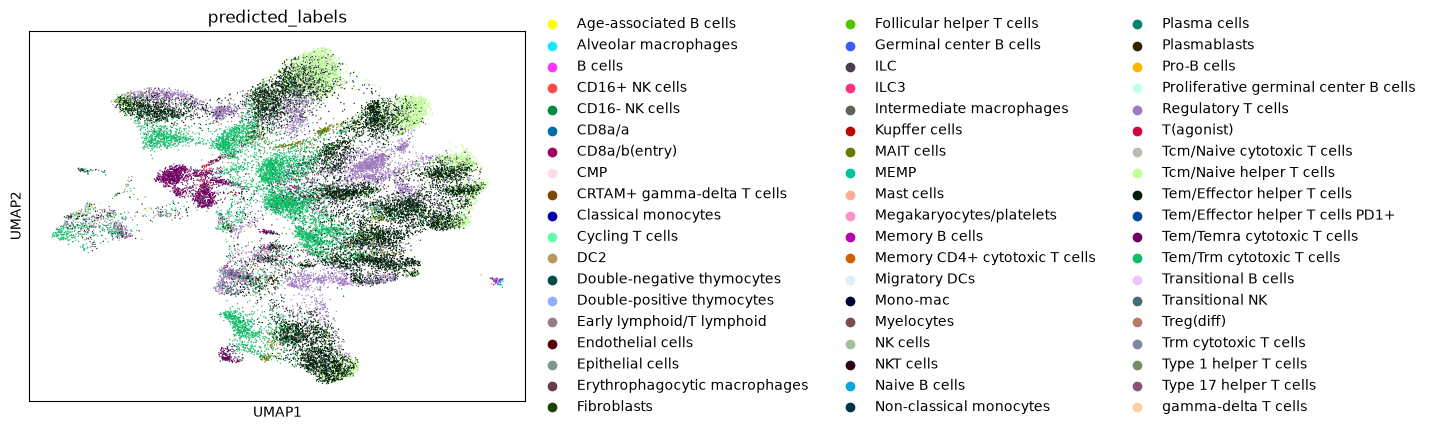

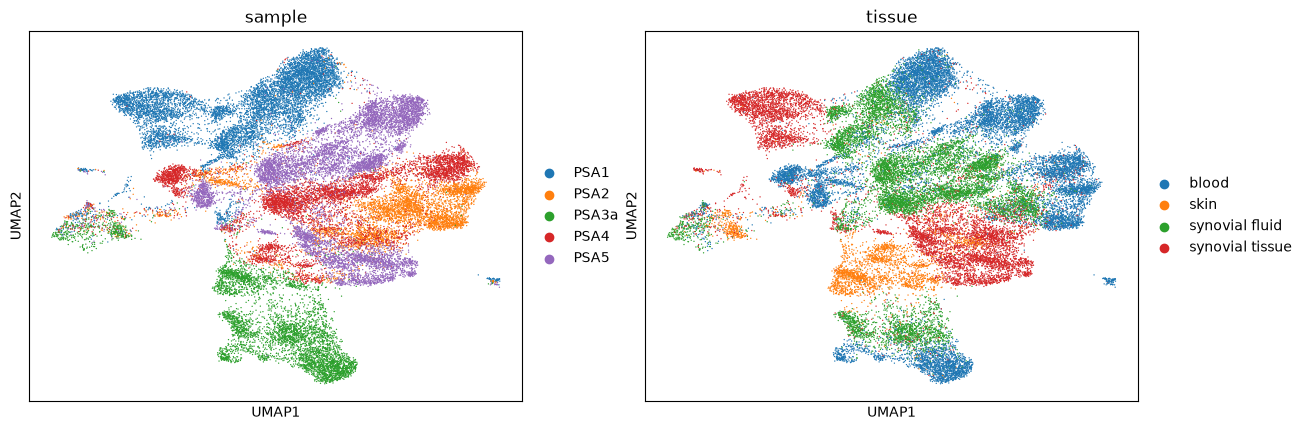

In [6]:
sc.pl.umap(
  mdata['gex'],
  color=["predicted_labels"],
)

sc.pl.umap(
  mdata['gex'],
  color=["sample", "tissue"],
)

... storing 'gex:sample' as categorical
... storing 'gex:patient' as categorical


... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:patient' as categorical


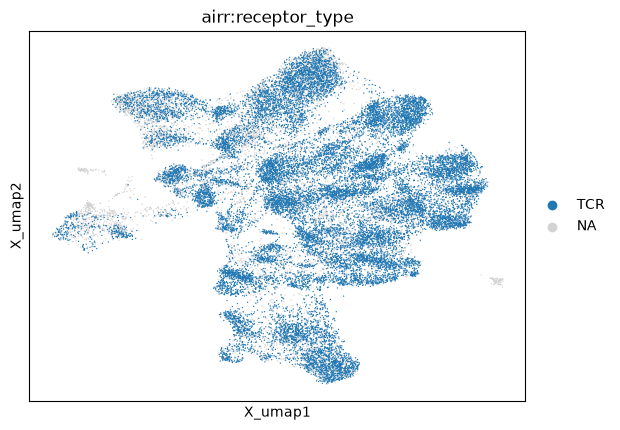

In [7]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_type"],
  ncols=3,
  wspace=0.7,
)

In [8]:
mdata["gex"].obs["predicted_labels"].value_counts()

predicted_labels
Tem/Effector helper T cells              12560
Tem/Trm cytotoxic T cells                 6749
Regulatory T cells                        4920
Tcm/Naive helper T cells                  4252
Tem/Temra cytotoxic T cells               1995
MAIT cells                                 586
Type 1 helper T cells                      325
Type 17 helper T cells                     152
Trm cytotoxic T cells                      129
Tcm/Naive cytotoxic T cells                123
CRTAM+ gamma-delta T cells                  93
Follicular helper T cells                   84
Proliferative germinal center B cells       68
CD16+ NK cells                              60
Naive B cells                               51
Memory B cells                              48
NKT cells                                   41
NK cells                                    39
Plasmablasts                                34
Memory CD4+ cytotoxic T cells               31
Treg(diff)                                 

In [9]:
mdata["airr"].obs["chain_pairing"].value_counts()

chain_pairing
single pair    22818
Name: count, dtype: int64

In [10]:
counts = pd.concat({
    "n_T": mdata["gex"].obs.groupby(["tissue", "sample"], observed=True).size(),
}, axis=1).fillna(0).astype(int)

counts

n_T
tissue          sample      
blood           PSA1    3133
                PSA2    2276
                PSA3a   1927
                PSA4    2032
                PSA5    2982
skin            PSA1      31
                PSA2     233
                PSA3a   1463
                PSA4     917
synovial fluid  PSA1    2519
                PSA2    1056
                PSA3a   1783
                PSA4    2194
                PSA5    2596
synovial tissue PSA1    2444
                PSA2    1333
                PSA3a    155
                PSA4     906
                PSA5    2586

In [11]:
counts = pd.concat({
    "n_T": mdata["gex"].obs.groupby(["tissue", "sample"], observed=True).size(),
}, axis=1).fillna(0).astype(int)

counts

n_T
tissue          sample      
blood           PSA1    3133
                PSA2    2276
                PSA3a   1927
                PSA4    2032
                PSA5    2982
skin            PSA1      31
                PSA2     233
                PSA3a   1463
                PSA4     917
synovial fluid  PSA1    2519
                PSA2    1056
                PSA3a   1783
                PSA4    2194
                PSA5    2596
synovial tissue PSA1    2444
                PSA2    1333
                PSA3a    155
                PSA4     906
                PSA5    2586

In [12]:
mdata

MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'sample_colors', 'tissue_colors', 'airr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient'
      obsm:	'airr', 'chain_indices'

In [13]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

mdata

MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'sample_colors', 'tissue_colors', 'airr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [14]:
airr = mdata['airr']
airr.obs['tissue'] = mdata['gex'].obs['tissue'].reindex(airr.obs_names)
obs = airr.obs

obs = mdata['airr'].obs
n_clonotypes = obs['clone_id'].unique().shape[0]
max_clonotype = obs['clone_id_size'].max().item()

print(f"Number of clonotypes: {n_clonotypes}")
print(f"Largest clonotype: {max_clonotype}")

Number of clonotypes: 16629
Largest clonotype: 180


In [15]:
largest_clonotype = obs[obs['clone_id_size'] == max_clonotype].iloc[0]['clone_id']
print(f"Largest clonotype id: {largest_clonotype}")

obs[obs['clone_id'] == largest_clonotype]['sample'].value_counts()

Largest clonotype id: 9735


sample
PSA4    180
Name: count, dtype: int64

In [16]:
ir.pp.ir_dist(
  mdata,
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

... storing 'gex:sample' as categorical
... storing 'gex:patient' as categorical
... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:clone_id' as categorical
... storing 'airr:cc_aa_tcrdist' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_subtype' as categorical
... storing 'chain_pairing' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'clone_id' as categorical
... storing 'cc_aa_tcrdist' as categorical


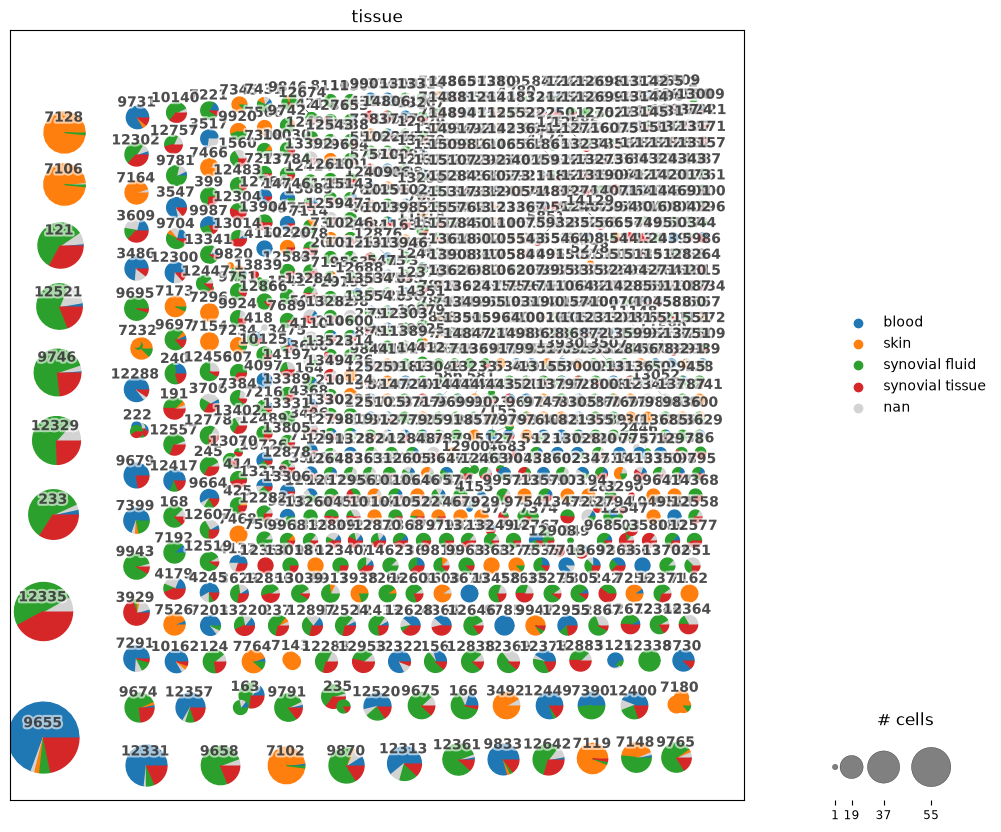

In [17]:
_ = ir.pl.clonotype_network(mdata, color="tissue")

In [18]:
cells = obs[obs['cc_aa_tcrdist'].isin(['7106', '7128'])]
pd.crosstab(cells['cc_aa_tcrdist'], cells['tissue'])

tissue,skin,synovial fluid
cc_aa_tcrdist,,
7106,60,1
7128,60,1


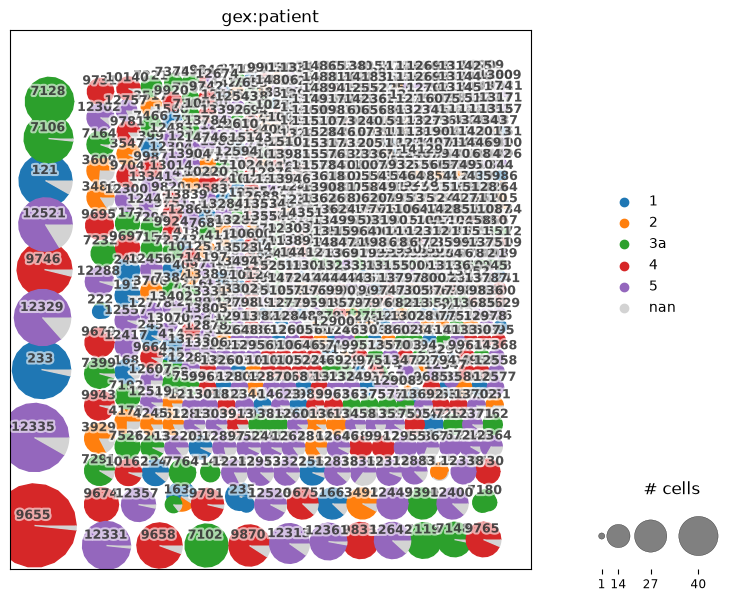

In [19]:
_ = ir.pl.clonotype_network(mdata, color="gex:patient", label_fontsize=9, panel_size=(7, 7), base_size=20)

In [20]:
obs = mdata.obs
cells = obs[obs['airr:cc_aa_tcrdist'].isin(['7106', '7128'])]
pd.crosstab(cells['airr:cc_aa_tcrdist'], cells['gex:predicted_labels']).T

airr:cc_aa_tcrdist,7106,7128
gex:predicted_labels,,
CD8a/a,0,1
Cycling T cells,1,0
Mono-mac,1,0
Naive B cells,0,1
Proliferative germinal center B cells,1,0
Regulatory T cells,29,30
Tem/Effector helper T cells,9,6
Tem/Temra cytotoxic T cells,6,2
Tem/Trm cytotoxic T cells,5,18


In [21]:
ir.tl.clonal_expansion(mdata, breakpoints=(1, 2, 5))
mdata

MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'sample_colors', 'tissue_colors', 'airr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'clone_id', 'clone_id_size', 'tissue', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist', 'clonotype_network', 'tissue_colors'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

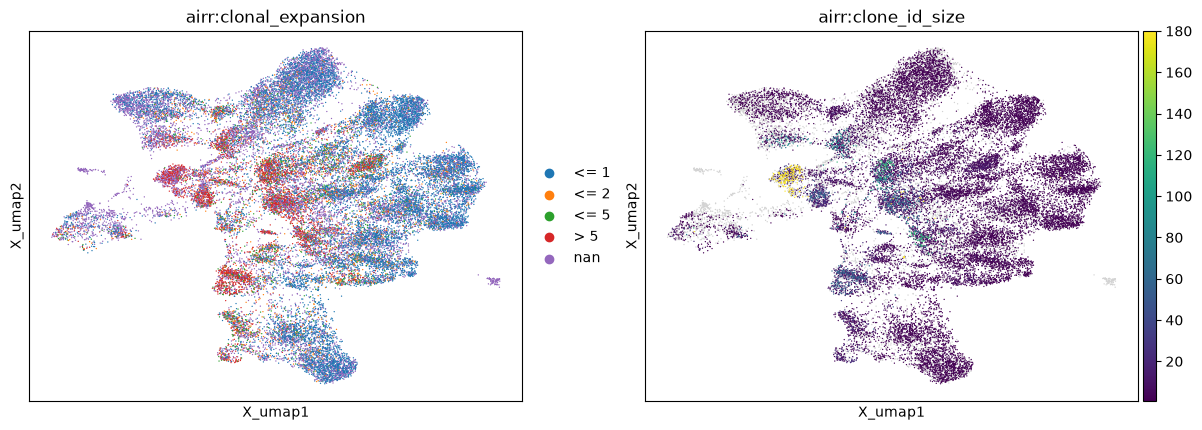

In [22]:
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"])

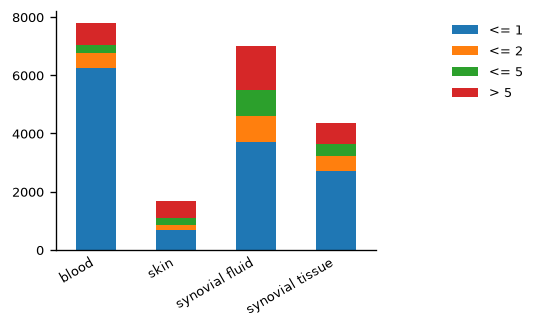

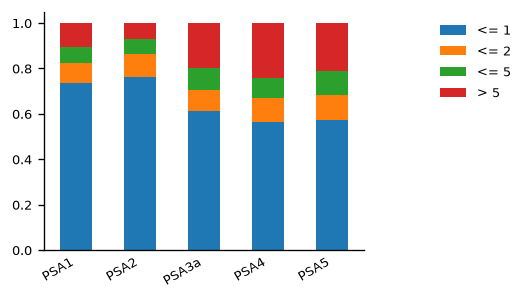

In [23]:
_ = ir.pl.clonal_expansion(mdata, target_col="clone_id", groupby="gex:tissue", breakpoints=(1, 2, 5), normalize=False)

_ = ir.pl.clonal_expansion(mdata, target_col="clone_id", groupby="gex:sample", breakpoints=(1, 2, 5), normalize=True)

In [24]:
df, _, _ = ir.tl.repertoire_overlap(mdata, "gex:tissue", inplace=False)

corr = df.T.corr(method="pearson")
corr

gex:tissue,blood,skin,synovial fluid,synovial tissue
gex:tissue,,,,
blood,1.000000,-0.007451,-0.000542,0.265581
skin,-0.007451,1.000000,0.004880,-0.012962
synovial fluid,-0.000542,0.004880,1.000000,0.538663
synovial tissue,0.265581,-0.012962,0.538663,1.000000
